In [2]:
import pandas as pd
import statsmodels
import requests

In [3]:
LAT, LON = 56.1629, 10.2039  # Aarhus
START, END = "2025-04-18", "2026-04-18"

# ── 1. Historical air quality (NO2, O3) ──────────────────────────────────────
print("Fetching air quality...")
aq = requests.get(
    "https://air-quality-api.open-meteo.com/v1/air-quality",
    params={
        "latitude": LAT,
        "longitude": LON,
        "hourly": "nitrogen_dioxide,ozone,pm10,pm2_5",
        "start_date": START,
        "end_date": END,
        "timezone": "Europe/Copenhagen"
    }
).json()

aq_df = pd.DataFrame({
    "Recorded": pd.to_datetime(aq["hourly"]["time"]),
    "NO2":      aq["hourly"]["nitrogen_dioxide"],
    "O3":       aq["hourly"]["ozone"],
    "PM10":     aq["hourly"]["pm10"],
    "PM2.5":    aq["hourly"]["pm2_5"],
})

# ── 2. Historical weather (wind, rain, temp, radiation) ──────────────────────
print("Fetching weather...")
wx = requests.get(
    "https://archive-api.open-meteo.com/v1/archive",
    params={
        "latitude": LAT,
        "longitude": LON,
        "hourly": "wind_speed_10m,wind_direction_10m,temperature_2m,shortwave_radiation,precipitation,relative_humidity_2m",
        "wind_speed_unit": "ms",
        "start_date": START,
        "end_date": END,
        "timezone": "Europe/Copenhagen"
    }
).json()

wx_df = pd.DataFrame({
    "Recorded":           pd.to_datetime(wx["hourly"]["time"]),
    "wind_speed":         wx["hourly"]["wind_speed_10m"],
    "temperature":        wx["hourly"]["temperature_2m"],
    "solar_radiation":    wx["hourly"]["shortwave_radiation"],
    "precipitation":      wx["hourly"]["precipitation"],
    "humidity":           wx["hourly"]["relative_humidity_2m"],

})

# ── 3. Merge and save ─────────────────────────────────────────────────────────
print("Merging...")
df = aq_df.merge(wx_df, on="Recorded", how="inner")
df = df.sort_values("Recorded").reset_index(drop=True)

print(f"\nFinal shape: {df.shape}")
print(df.head())
print(f"\nDate range: {df.Recorded.min()} → {df.Recorded.max()}")
print(f"Missing values:\n{df.isnull().sum()}")

df.to_csv("aarhus_air_quality.csv", index=False)
print("\nSaved to aarhus_air_quality.csv")

Fetching air quality...
Fetching weather...
Merging...

Final shape: (8784, 10)
             Recorded  NO2    O3  PM10  PM2.5  wind_speed  temperature  \
0 2025-04-18 00:00:00  3.4  90.0   3.8    2.9        4.52          8.3   
1 2025-04-18 01:00:00  3.1  91.0   3.2    2.6        4.51          7.9   
2 2025-04-18 02:00:00  2.5  95.0   3.0    2.1        4.40          7.8   
3 2025-04-18 03:00:00  2.7  92.0   3.1    2.0        4.44          7.8   
4 2025-04-18 04:00:00  2.6  87.0   3.4    2.6        4.70          7.8   

   solar_radiation  precipitation  humidity  
0              0.0            0.0        86  
1              0.0            0.0        87  
2              0.0            0.0        86  
3              0.0            0.0        91  
4              0.0            0.0        89  

Date range: 2025-04-18 00:00:00 → 2026-04-18 23:00:00
Missing values:
Recorded           0
NO2                0
O3                 0
PM10               0
PM2.5              0
wind_speed         0
te

In [3]:
df.head()

,Recorded,NO2,O3,PM10,PM2.5,wind_speed,wind_direction,temperature,solar_radiation,precipitation,humidity
0,2022-01-01 00:00:00,6.2,53.0,6.2,5.0,5.00,269,6.7,0.0,0.0,98
1,2022-01-01 01:00:00,4.6,53.0,6.4,4.7,5.00,272,7.2,0.0,0.0,98
2,2022-01-01 02:00:00,5.0,57.0,6.0,4.5,4.90,269,7.1,0.0,0.0,97
3,2022-01-01 03:00:00,5.0,54.0,5.4,4.6,4.72,265,7.1,0.0,0.0,97
4,2022-01-01 04:00:00,5.7,52.0,5.3,4.9,4.53,264,7.1,0.0,0.0,96


In [15]:
df.iloc[:, 1:10]

,NO2,O3,PM10,PM2.5,wind_speed,wind_direction,temperature,solar_radiation,precipitation
0,6.2,53.0,6.2,5.0,5.00,269,6.7,0.0,0.0
1,4.6,53.0,6.4,4.7,5.00,272,7.2,0.0,0.0
2,5.0,57.0,6.0,4.5,4.90,269,7.1,0.0,0.0
3,5.0,54.0,5.4,4.6,4.72,265,7.1,0.0,0.0
4,5.7,52.0,5.3,4.9,4.53,264,7.1,0.0,0.0
...,...,...,...,...,...,...,...,...,...
37651,9.9,72.0,12.1,10.4,2.17,151,9.2,47.0,0.3
37652,10.7,67.0,11.6,10.4,1.90,166,9.3,20.0,0.2
37653,11.6,58.0,11.5,10.4,1.96,176,9.1,1.0,0.1
37654,10.7,51.0,11.7,10.6,2.08,207,9.1,0.0,0.0


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt 

In [6]:
from statsmodels.tsa.stattools import ccf
import numpy as np

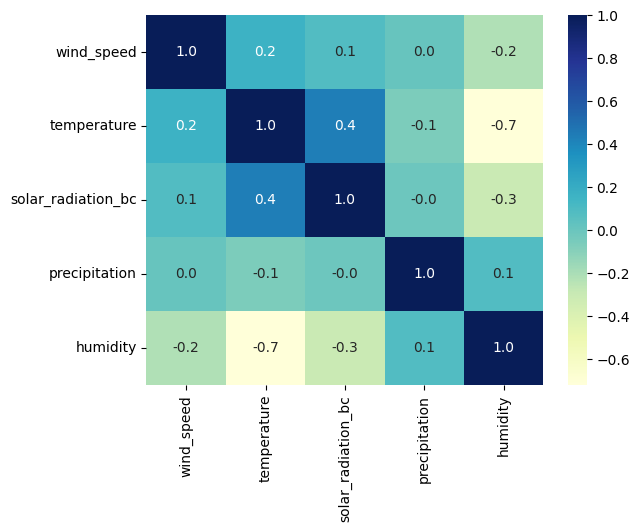

In [19]:
from scipy.stats import boxcox
def difference_exog(df, exog_cols, m):
    df_diff = df[exog_cols].copy()
    
    for col in exog_cols:
        df_diff[col] = df[col] - df[col].shift(m)        # seasonal diff
        df_diff[col] = df_diff[col] - df_diff[col].shift(1)  # first diff on top
    
    return df_diff.dropna()

df['solar_radiation_bc'], lambda_ = boxcox(df['solar_radiation'] + 1)
exg_columns = ['wind_speed', 'temperature', 'solar_radiation_bc', 'precipitation', 'humidity']
df_diff = difference_exog(df, exg_columns, m=7)

co_mtx = df_diff.corr()
sns.heatmap(co_mtx, cmap="YlGnBu", annot=True, fmt=".1f")
plt.show()

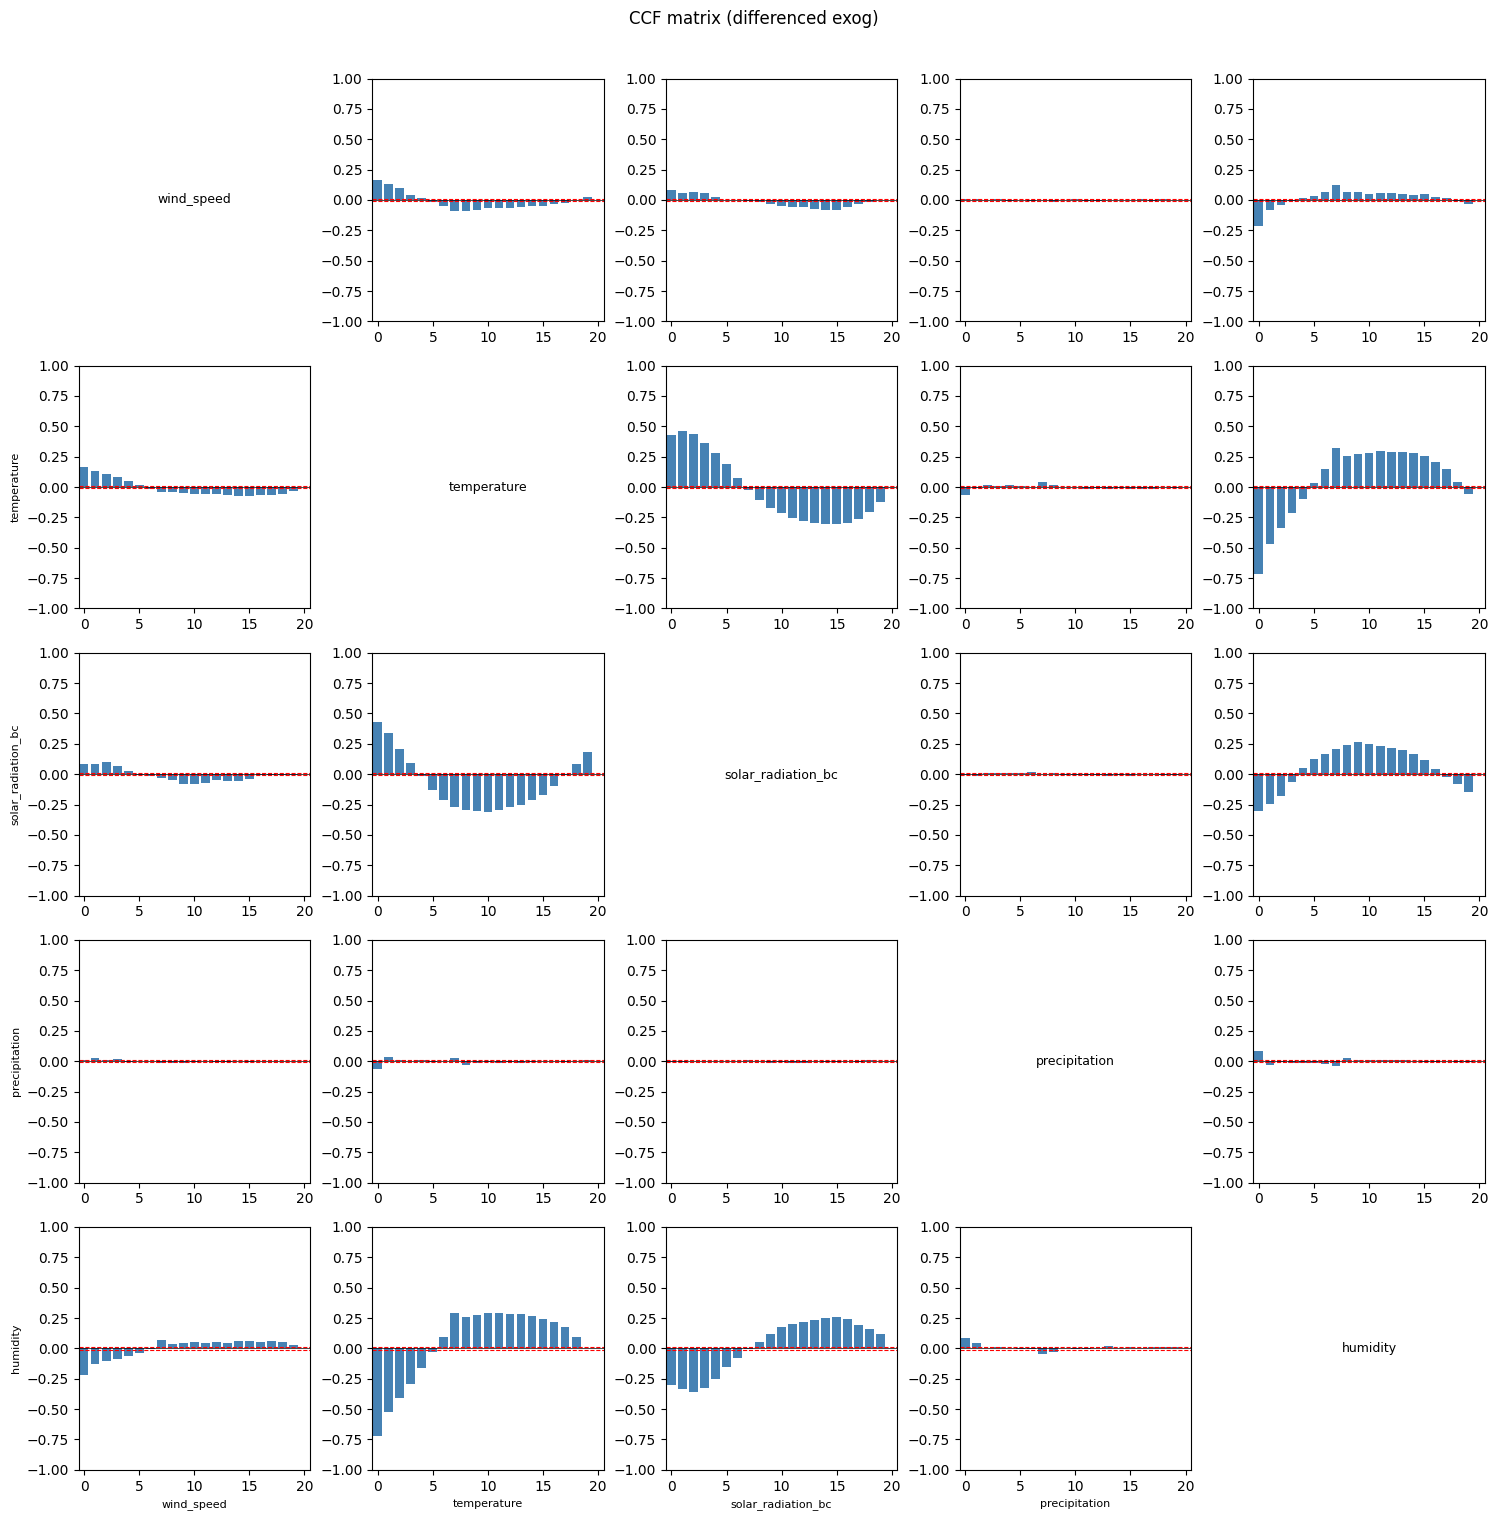

In [20]:
# plot CCF for exogenous variables

def plot_ccf_matrix(df_diff, exog_cols, lags=20):
    n = len(exog_cols)
    fig, axes = plt.subplots(n, n, figsize=(n * 3, n * 3))
    
    for i, col_i in enumerate(exog_cols):
        for j, col_j in enumerate(exog_cols):
            ax = axes[i, j]
            
            if i == j:
                ax.text(0.5, 0.5, col_i, transform=ax.transAxes,
                        ha='center', va='center', fontsize=9, wrap=True)
                ax.set_axis_off()
                continue
            
            x = df_diff[col_i].values
            y = df_diff[col_j].values
            
            ccf_vals = ccf(x, y, nlags=lags, adjusted=False)
            
            # confidence interval at 95%
            ci = 1.96 / np.sqrt(len(x))
            
            ax.bar(range(len(ccf_vals)), ccf_vals, color='steelblue', width=0.8)
            ax.axhline(ci,  color='red', linestyle='--', linewidth=0.8)
            ax.axhline(-ci, color='red', linestyle='--', linewidth=0.8)
            ax.axhline(0,   color='black', linewidth=0.5)
            ax.set_xlim(-0.5, lags + 0.5)
            ax.set_ylim(-1, 1)
            
            if i == n - 1:
                ax.set_xlabel(col_j, fontsize=8)
            if j == 0:
                ax.set_ylabel(col_i, fontsize=8)
    
    plt.suptitle('CCF matrix (differenced exog)', y=1.01)
    plt.tight_layout()
    plt.show()

plot_ccf_matrix(df_diff, exg_columns, lags=20)

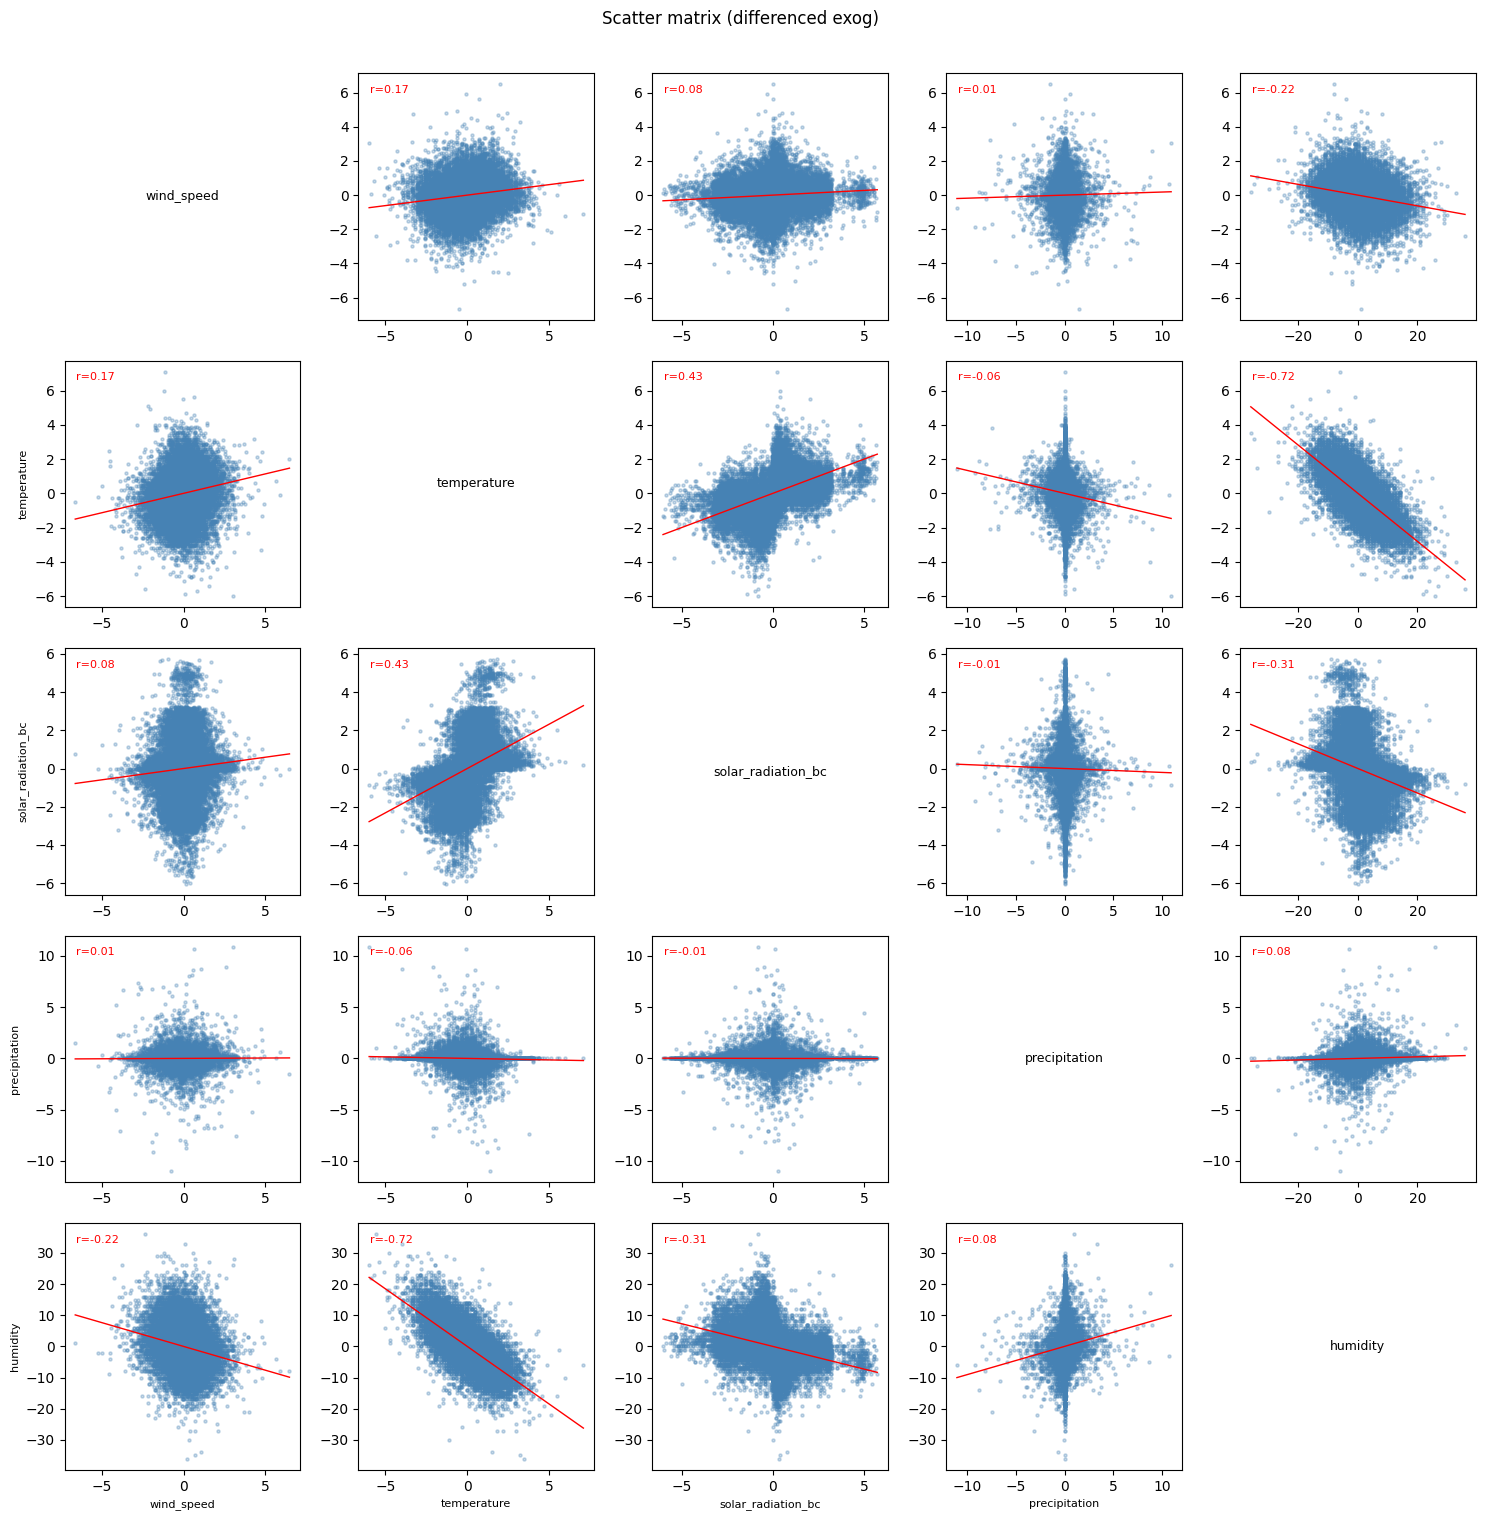

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def plot_scatter_matrix(df_diff, exog_cols):
    n = len(exog_cols)
    fig, axes = plt.subplots(n, n, figsize=(n * 3, n * 3))

    for i, col_i in enumerate(exog_cols):
        for j, col_j in enumerate(exog_cols):
            ax = axes[i, j]

            if i == j:
                ax.text(0.5, 0.5, col_i, transform=ax.transAxes,
                        ha='center', va='center', fontsize=9)
                ax.set_axis_off()
                continue

            x = df_diff[col_j].values
            y = df_diff[col_i].values

            ax.scatter(x, y, alpha=0.3, s=5, color='steelblue')

            slope, intercept, r, _, _ = stats.linregress(x, y)
            x_line = np.linspace(x.min(), x.max(), 100)
            ax.plot(x_line, slope * x_line + intercept, color='red', linewidth=1)

            ax.text(0.05, 0.92, f'r={r:.2f}', transform=ax.transAxes,
                    fontsize=8, color='red')

            if i == n - 1:
                ax.set_xlabel(col_j, fontsize=8)
            if j == 0:
                ax.set_ylabel(col_i, fontsize=8)

    plt.suptitle('Scatter matrix (differenced exog)', y=1.01)
    plt.tight_layout()
    plt.show()

plot_scatter_matrix(df_diff, exg_columns)

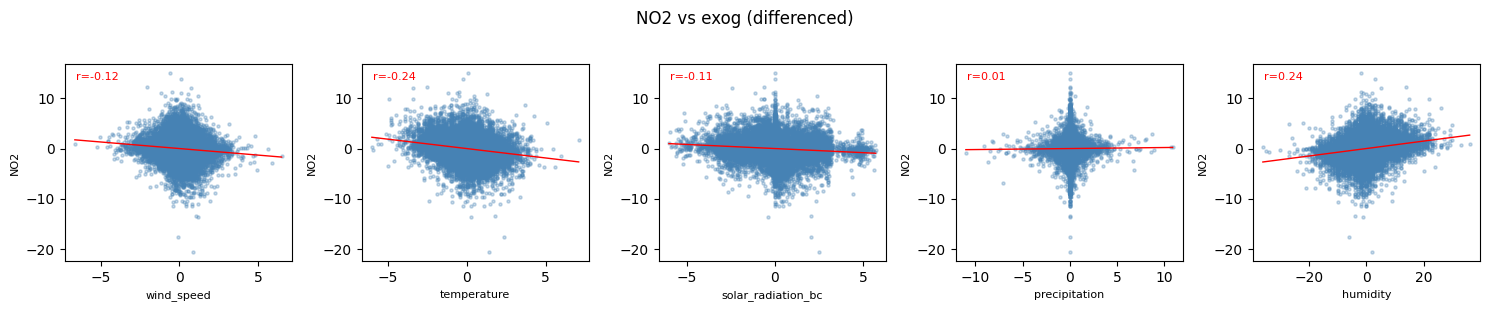

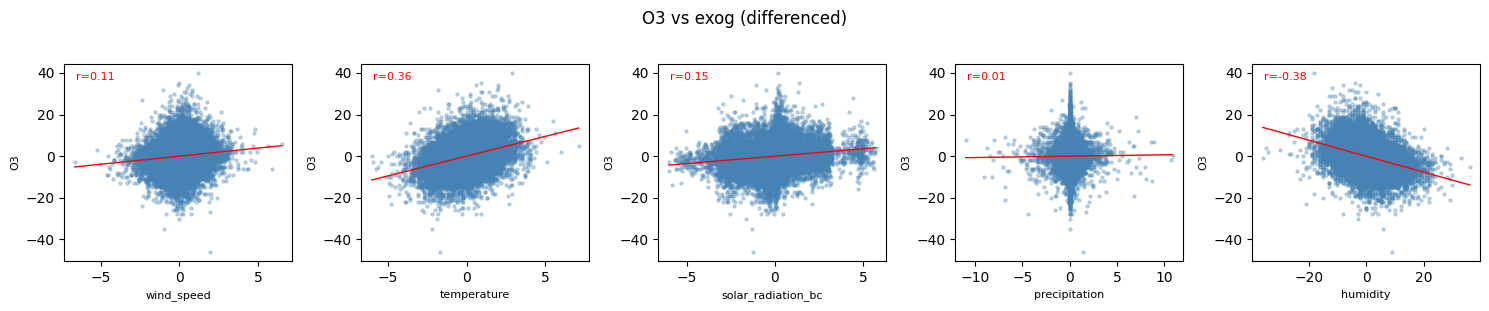

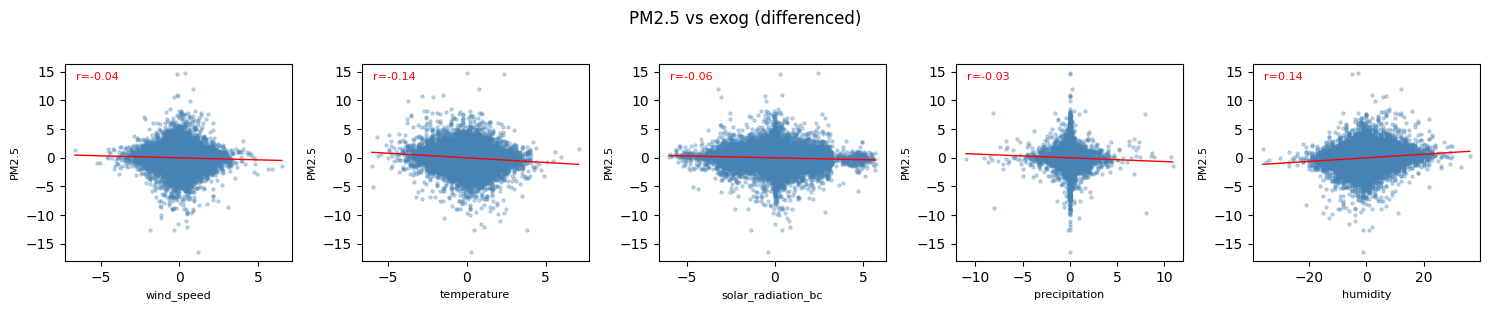

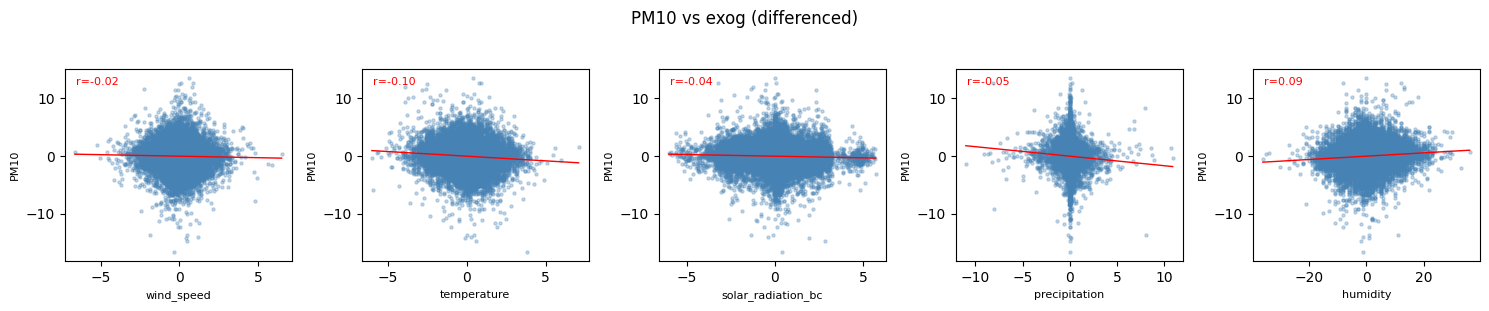

In [22]:
def difference_target(df, target_cols, m):
    df_diff = df[target_cols].copy()
    
    for col in target_cols:
        df_diff[col] = df[col] - df[col].shift(m)
        df_diff[col] = df_diff[col] - df_diff[col].shift(1)
    
    return df_diff

target_cols = ['NO2', 'O3', 'PM2.5', 'PM10']

df_target_diff = difference_target(df, target_cols, m=7)

# align indices after dropping NaNs
combined = pd.concat([df_diff, df_target_diff], axis=1).dropna()
df_exog_aligned = combined[exg_columns]
df_target_aligned = combined[target_cols]


def plot_target_vs_exog(df_exog, df_target, target_cols, exog_cols):
    for target in target_cols:
        n = len(exog_cols)
        fig, axes = plt.subplots(1, n, figsize=(n * 3, 3))

        for j, exog in enumerate(exog_cols):
            ax = axes[j]

            x = df_exog[exog].values
            y = df_target[target].values

            ax.scatter(x, y, alpha=0.3, s=5, color='steelblue')

            slope, intercept, r, _, _ = stats.linregress(x, y)
            x_line = np.linspace(x.min(), x.max(), 100)
            ax.plot(x_line, slope * x_line + intercept, color='red', linewidth=1)

            ax.text(0.05, 0.92, f'r={r:.2f}', transform=ax.transAxes,
                    fontsize=8, color='red')

            ax.set_xlabel(exog, fontsize=8)
            ax.set_ylabel(target, fontsize=8)

        plt.suptitle(f'{target} vs exog (differenced)', y=1.02)
        plt.tight_layout()
        plt.show()

plot_target_vs_exog(df_exog_aligned, df_target_aligned, target_cols, exg_columns)

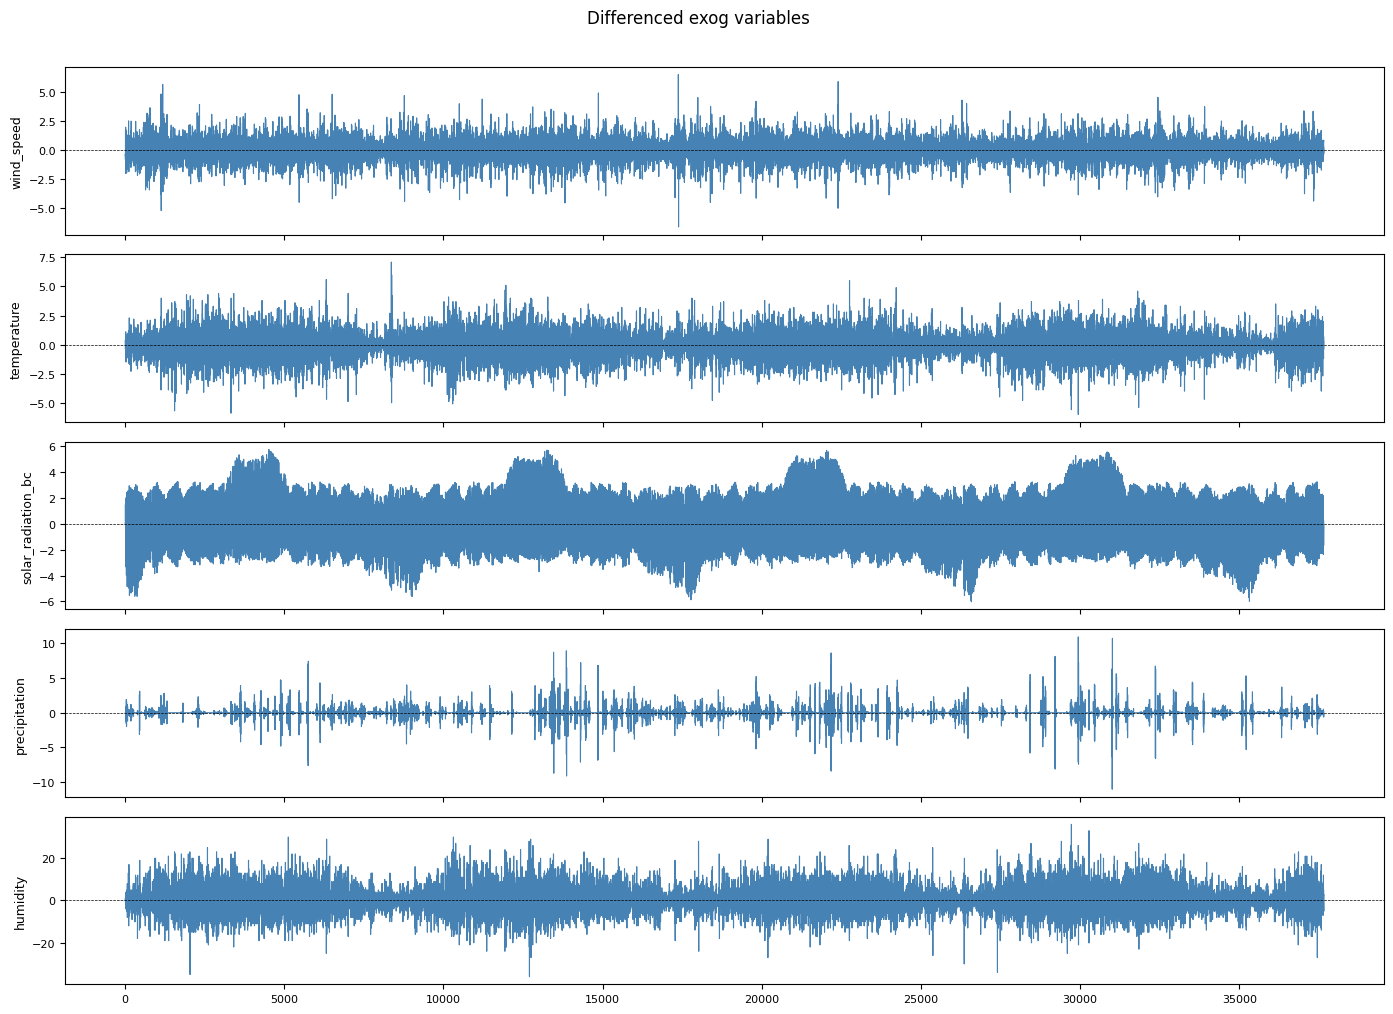

In [23]:
def plot_differenced_exog(df_diff, exog_cols):
    n = len(exog_cols)
    fig, axes = plt.subplots(n, 1, figsize=(14, n * 2))

    for i, col in enumerate(exog_cols):
        ax = axes[i]
        ax.plot(df_diff.index, df_diff[col], linewidth=0.8, color='steelblue')
        ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
        ax.set_ylabel(col, fontsize=9)
        ax.tick_params(labelsize=8)

        if i < n - 1:
            ax.set_xticklabels([])

    plt.suptitle('Differenced exog variables', y=1.01)
    plt.tight_layout()
    plt.show()

plot_differenced_exog(df_diff, exg_columns)

/var/folders/cs/2bnp73454cs1yhd6mzz1w2cc0000gn/T/ipykernel_21570/623480150.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(grouped, labels=day_labels, patch_artist=True,
/var/folders/cs/2bnp73454cs1yhd6mzz1w2cc0000gn/T/ipykernel_21570/623480150.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(grouped, labels=day_labels, patch_artist=True,
/var/folders/cs/2bnp73454cs1yhd6mzz1w2cc0000gn/T/ipykernel_21570/623480150.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(grouped, labels=day_labels, patch_artist=True,
/var/folders/cs/2bnp73454cs1yhd6mzz1w2cc0000gn/T/ipykernel_21570/62

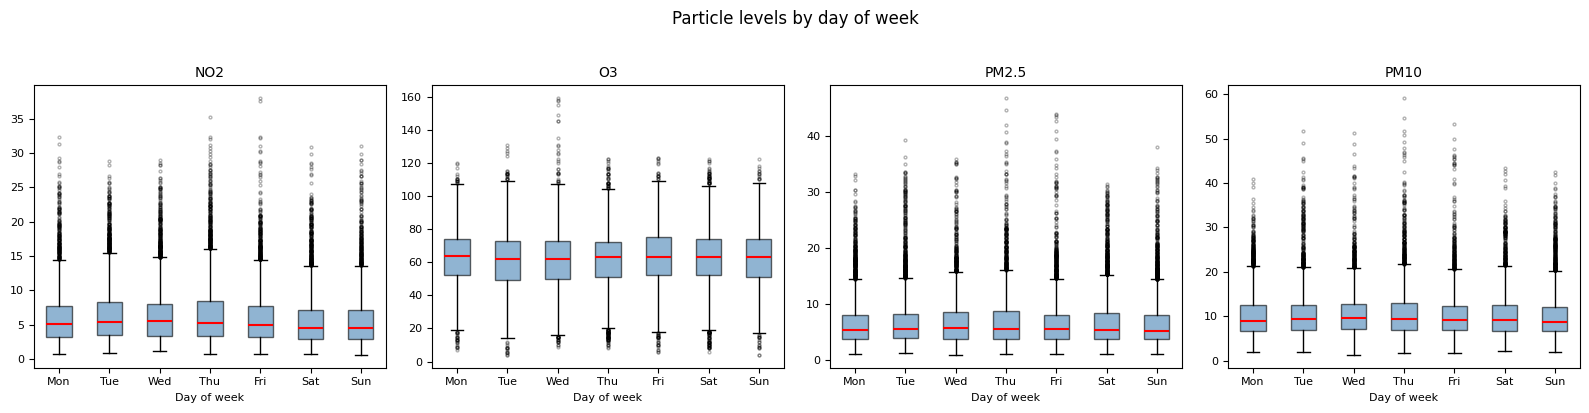

In [24]:
def plot_dow_correlation(df, target_cols, datetime_col='Recorded'):
    df = df.copy()
    df['dow'] = pd.to_datetime(df[datetime_col]).dt.dayofweek  # 0=Monday, 6=Sunday
    day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

    fig, axes = plt.subplots(1, len(target_cols), figsize=(len(target_cols) * 4, 4))

    for i, col in enumerate(target_cols):
        ax = axes[i]

        grouped = [df[df['dow'] == d][col].dropna().values for d in range(7)]

        ax.boxplot(grouped, labels=day_labels, patch_artist=True,
                   boxprops=dict(facecolor='steelblue', alpha=0.6),
                   medianprops=dict(color='red', linewidth=1.5),
                   flierprops=dict(marker='o', markersize=2, alpha=0.3))

        ax.set_title(col, fontsize=10)
        ax.set_xlabel('Day of week', fontsize=8)
        ax.tick_params(labelsize=8)

    plt.suptitle('Particle levels by day of week', y=1.02)
    plt.tight_layout()
    plt.show()

plot_dow_correlation(df, target_cols)

In [12]:
df.head()

,Recorded,NO2,O3,PM10,PM2.5,wind_speed,wind_direction,temperature,solar_radiation,precipitation,humidity
0,2022-01-01 00:00:00,6.2,53.0,6.2,5.0,5.00,269,6.7,0.0,0.0,98
1,2022-01-01 01:00:00,4.6,53.0,6.4,4.7,5.00,272,7.2,0.0,0.0,98
2,2022-01-01 02:00:00,5.0,57.0,6.0,4.5,4.90,269,7.1,0.0,0.0,97
3,2022-01-01 03:00:00,5.0,54.0,5.4,4.6,4.72,265,7.1,0.0,0.0,97
4,2022-01-01 04:00:00,5.7,52.0,5.3,4.9,4.53,264,7.1,0.0,0.0,96


In [ ]:
from sklearn.preprocessing import StandardScaler

exg_columns = ['wind_speed', 'temperature', 'solar_radiation', 'precipitation', 'humidity']

sc = StandardScaler()
df[exg_columns] = sc.fit_transform(df[exg_columns])

In [7]:
df

,Recorded,NO2,O3,PM10,PM2.5,wind_speed,wind_direction,temperature,solar_radiation,precipitation,humidity
0,2022-01-01 00:00:00,6.2,53.0,6.2,5.0,0.155297,0.766842,-0.364411,-0.630513,-0.241423,1.293085
1,2022-01-01 01:00:00,4.6,53.0,6.4,4.7,0.155297,0.801969,-0.287115,-0.630513,-0.241423,1.293085
2,2022-01-01 02:00:00,5.0,57.0,6.0,4.5,0.109520,0.766842,-0.302574,-0.630513,-0.241423,1.216653
3,2022-01-01 03:00:00,5.0,54.0,5.4,4.6,0.027121,0.720006,-0.302574,-0.630513,-0.241423,1.216653
4,2022-01-01 04:00:00,5.7,52.0,5.3,4.9,-0.059855,0.708297,-0.302574,-0.630513,-0.241423,1.140222
...,...,...,...,...,...,...,...,...,...,...,...
37651,2026-04-18 19:00:00,9.9,72.0,12.1,10.4,-1.140190,-0.614827,0.022072,-0.390791,0.535412,0.834495
37652,2026-04-18 20:00:00,10.7,67.0,11.6,10.4,-1.263788,-0.439191,0.037531,-0.528504,0.276467,0.910927
37653,2026-04-18 21:00:00,11.6,58.0,11.5,10.4,-1.236322,-0.322100,0.006613,-0.625413,0.017522,0.987358
37654,2026-04-18 22:00:00,10.7,51.0,11.7,10.6,-1.181389,0.040881,0.006613,-0.630513,-0.241423,1.063790


In [14]:
import matplotlib.pyplot as plt

def differencing_plots(m, y):
    df['y_seasonal_diff'] = df[y] - df[y].shift(m)
    df['y_double_diff'] = df['y_seasonal_diff'] - df['y_seasonal_diff'].shift(1)

    plot_df = df.iloc[:300]

    fig, axes = plt.subplots(3, 1, figsize=(12, 8))

    axes[0].plot(plot_df[y])
    axes[0].set_title('Original series')

    axes[1].plot(plot_df['y_seasonal_diff'])
    axes[1].set_title(f'Seasonally differenced (m={m})')

    axes[2].plot(plot_df['y_double_diff'])
    axes[2].set_title(f'Seasonally + first differenced (m={m})')

    plt.tight_layout()
    plt.show()

In [27]:
import matplotlib.pyplot as plt

def differencing_plots(m, y):
    df['Recorded'] = pd.to_datetime(df['Recorded'])
    df['y_seasonal_diff'] = df[y] - df[y].shift(m)
    df['y_double_diff'] = df['y_seasonal_diff'] - df['y_seasonal_diff'].shift(1)

    plot_df = df.groupby([df['Recorded'].dt.dayofweek, df['Recorded'].dt.hour]).mean().reset_index(drop=True)

    days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    tick_positions = [i * 24 for i in range(7)]

    fig, axes = plt.subplots(3, 1, figsize=(12, 8))

    axes[0].plot(plot_df[y])
    axes[0].set_title('Original series (weekly average)')

    axes[1].plot(plot_df['y_seasonal_diff'])
    axes[1].set_title(f'Seasonally differenced (m={m}, weekly average)')

    axes[2].plot(plot_df['y_double_diff'])
    axes[2].set_title(f'Seasonally + first differenced (m={m}, weekly average)')

    for ax in axes:
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(days)

    plt.tight_layout()
    plt.show()

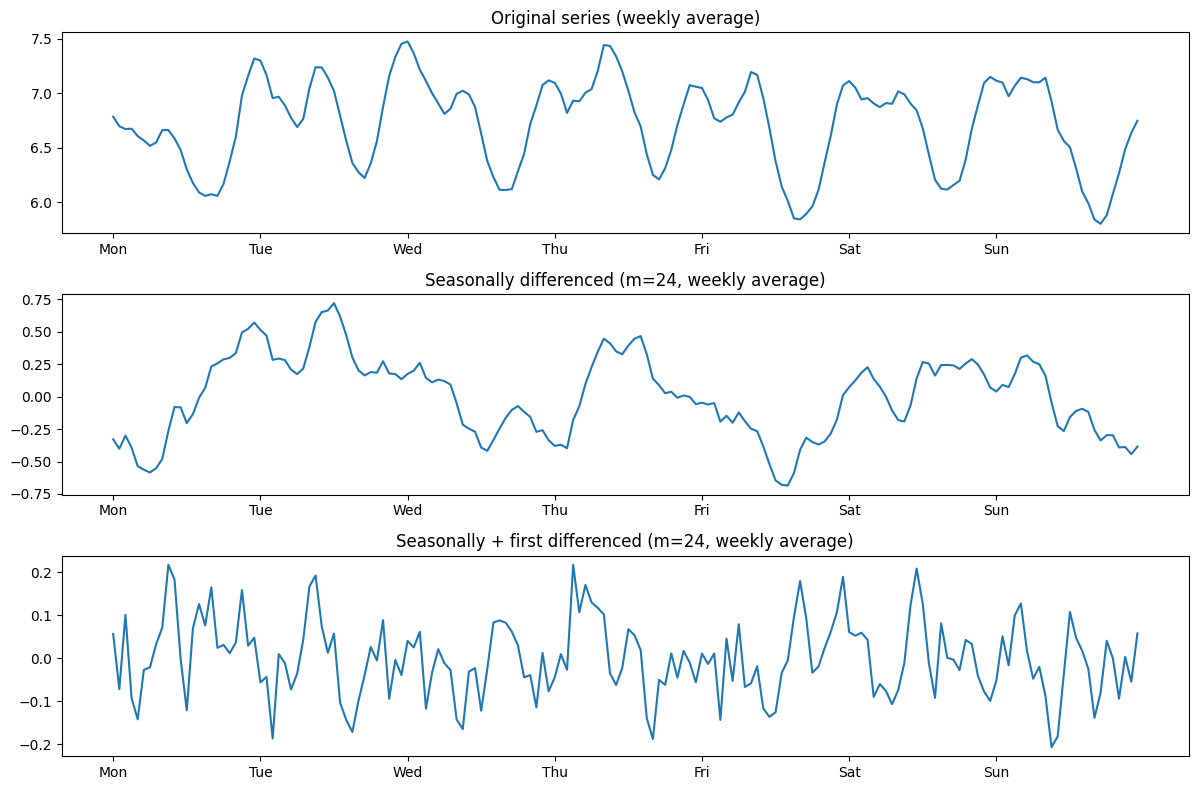

In [38]:
differencing_plots(24, 'PM2.5')

In [11]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
def differencing_plots(df, m, y):
    df = df.copy()
    df['Recorded'] = pd.to_datetime(df['Recorded'])
    df['y_seasonal_diff'] = df[y] - df[y].shift(m)
    df['y_double_diff'] = df['y_seasonal_diff'] - df['y_seasonal_diff'].shift(1)

    double_diff = df['y_double_diff'].dropna()

    fig, axes = plt.subplots(5, 1, figsize=(12, 14))

    axes[0].plot(df['Recorded'], df[y])
    axes[0].set_title('Original series')

    axes[1].plot(df['Recorded'].iloc[m:], df['y_seasonal_diff'].dropna())
    axes[1].set_title(f'Seasonally differenced (m={m})')

    axes[2].plot(df['Recorded'].iloc[m+1:], double_diff)
    axes[2].set_title(f'Seasonally + first differenced (m={m})')

    plot_acf(double_diff, lags=200, ax=axes[3], title='ACF — double differenced (lags=200)')
    plot_pacf(double_diff, lags=200, ax=axes[4], title='PACF — double differenced (lags=200)')

    plt.tight_layout()
    plt.show()

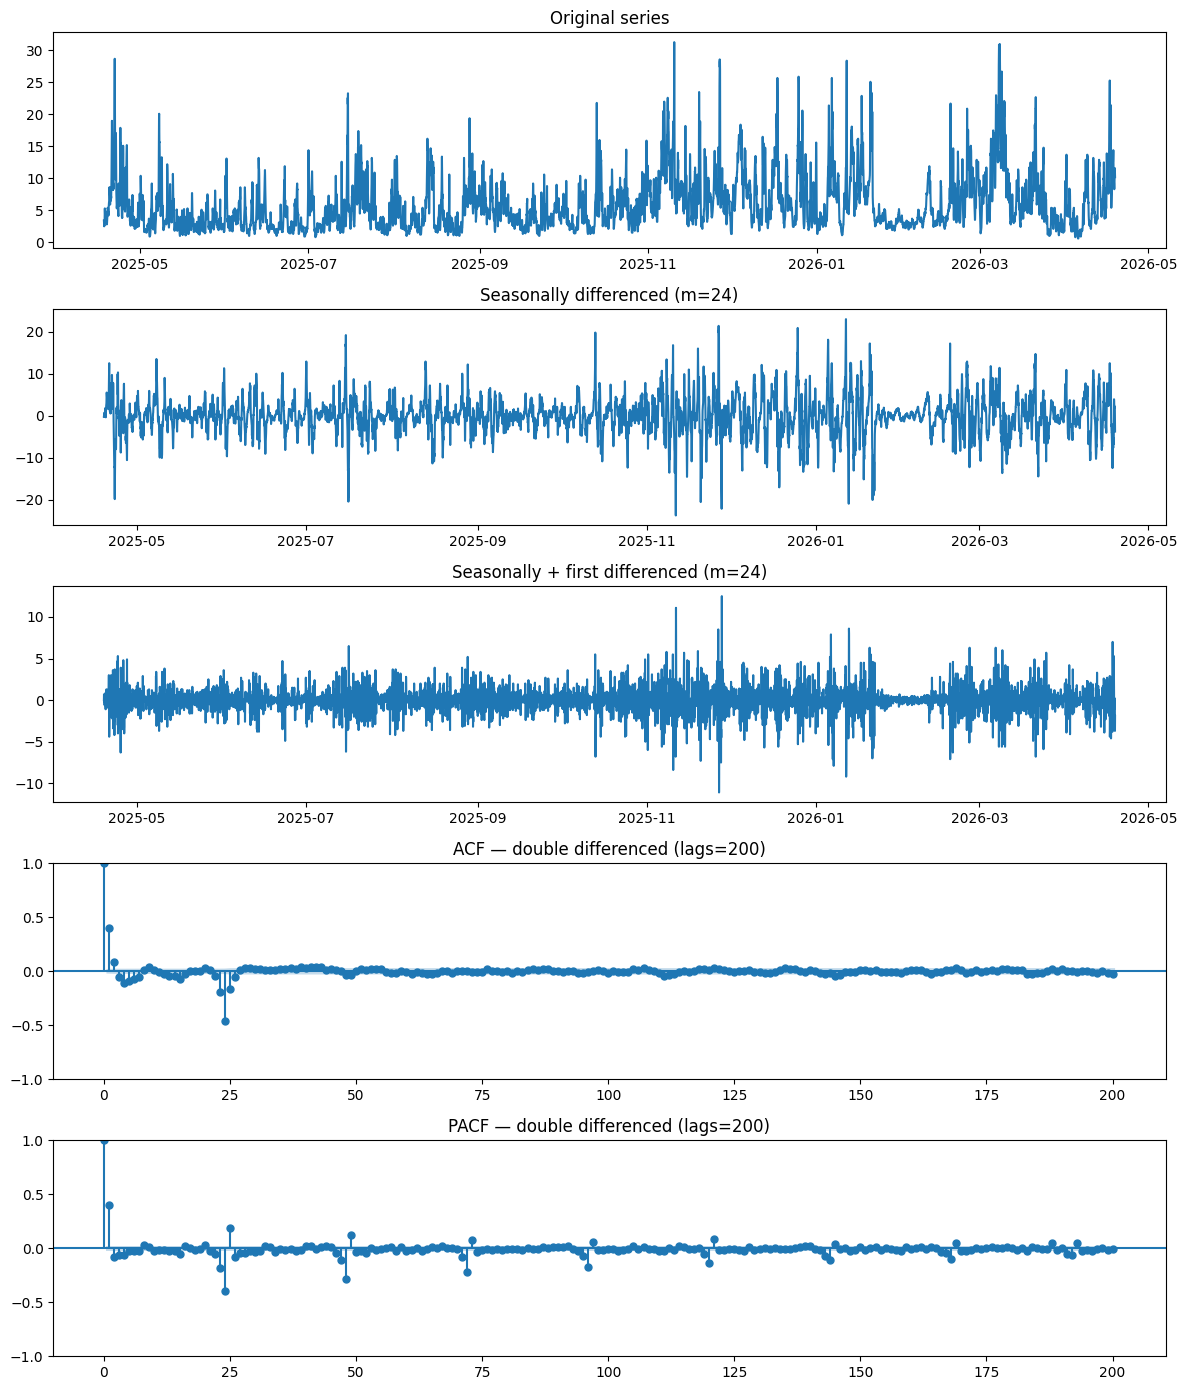

In [12]:
differencing_plots(df, 24, 'NO2')

In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def differencing_plots(df, m, y, D=1, d=1):
    df = df.copy()
    df['Recorded'] = pd.to_datetime(df['Recorded'])

    series = df[y].copy()
    timestamps = df['Recorded'].copy()
    n_plots = 1 + D + d + 2

    fig, axes = plt.subplots(n_plots, 1, figsize=(12, n_plots * 3))
    ax_idx = 0

    axes[ax_idx].plot(timestamps, series)
    axes[ax_idx].set_title('Original series')
    ax_idx += 1

    for i in range(1, D + 1):
        series = series - series.shift(m)
        timestamps = timestamps.iloc[m:]
        axes[ax_idx].plot(timestamps, series.dropna())
        axes[ax_idx].set_title(f'Seasonal differencing order {i} (m={m})')
        ax_idx += 1

    for i in range(1, d + 1):
        series = series - series.shift(1)
        timestamps = timestamps.iloc[1:]
        axes[ax_idx].plot(timestamps, series.dropna())
        axes[ax_idx].set_title(f'First order differencing order {i}')
        ax_idx += 1

    plot_acf(series.dropna(), lags=96, ax=axes[ax_idx], title='ACF (lags=96)')
    plot_pacf(series.dropna(), lags=96, ax=axes[ax_idx + 1], title='PACF (lags=96)')

    plt.tight_layout()
    plt.show()

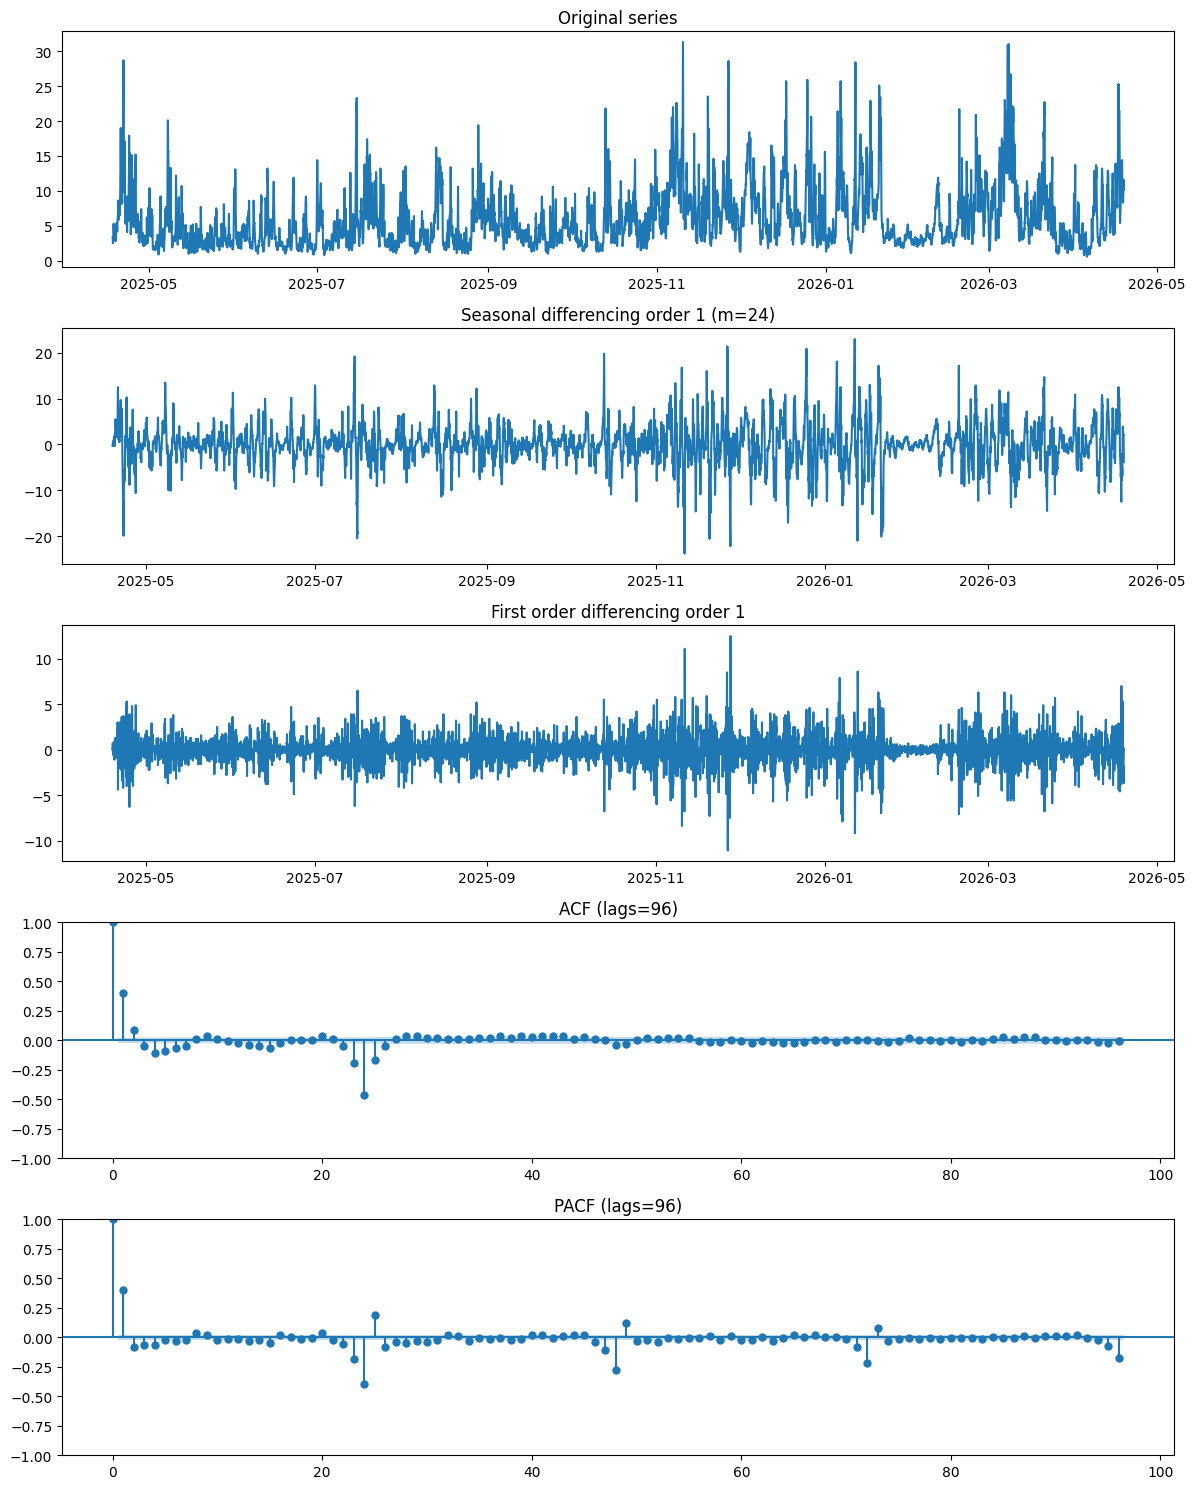

In [16]:
differencing_plots(df, 24, 'NO2', D=1, d=1)

Seed set to 1
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.8 M  | train
-------------------------------------------------------
2.8 M     Trainable params
0         Non-trainable params
2.8 M     Total params
11.220    Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode


/Users/louisebrixpilegaardhansen/Desktop/Uni/DataScience/air-quality-forecasting/.venv311/lib/python3.11/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Epoch 99: 100%|██████████| 1/1 [00:00<00:00, 33.91it/s, v_num=10, train_loss_step=8.330, train_loss_epoch=8.330]

`Trainer.fit` stopped: `max_steps=100` reached.


Epoch 99: 100%|██████████| 1/1 [00:00<00:00, 31.61it/s, v_num=10, train_loss_step=8.330, train_loss_epoch=8.330]


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 155.30it/s]


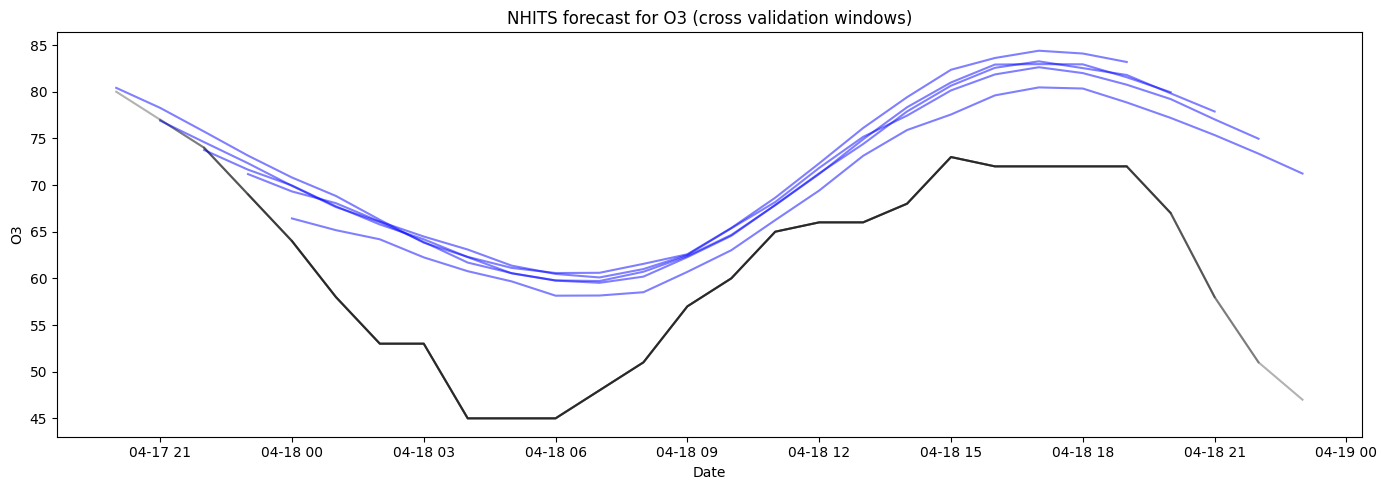

In [ ]:
from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS
import matplotlib.pyplot as plt 

exog_columns = ['wind_speed', 'wind_direction', 'temperature', 'solar_radiation', 'precipitation', 'humidity']

nf_df = df[['Recorded', 'O3'] + exog_columns].rename(columns={'Recorded': 'ds', 'O3': 'y'})
nf_df['unique_id'] = 'O3'
nf_df['ds'] = pd.to_datetime(nf_df['ds']).dt.tz_localize(None)

horizon = 24

model = NeuralForecast(
    models=[NHITS(
        h=horizon,
        input_size=48,
        hist_exog_list=exog_columns,
        max_steps=100,
    )],
    freq='H'
)

cv_results = model.cross_validation(nf_df, n_windows=5)

fig, ax = plt.subplots(figsize=(14, 5))

for window, group in cv_results.groupby('cutoff'):
    ax.plot(group['ds'], group['y'], color='black', alpha=0.3)
    ax.plot(group['ds'], group['NHITS'], color='blue', alpha=0.5)

ax.set_title('NHITS forecast for O3 (cross validation windows)')
ax.set_xlabel('Date')
ax.set_ylabel('O3')
plt.tight_layout()
plt.show()